<a href="https://colab.research.google.com/github/BODUNOVAsofia/python-ai-bodunova-sofia/blob/main/notebooks/week3_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 📥 [0] Подготовка данных: клонирование репозитория и загрузка CSV

**Что делаем:**
- Клонируем GitHub-репозиторий проекта в Google Colab
- Загружаем CSV-файл `paintings.csv` (1000 записей о картинах)
- Очищаем столбцы: удаляем URL Wikidata (`painting`), переименовываем `*Label` → короткие имена
- Приводим числовые поля (`height`, `width`, `creationYear`) к типу `int`

**Результат:** Чистая таблица `df_paintings` с полями:
- `painting` — название картины
- `country` — страна происхождения
- `material` — материал основы (холст, дерево и т.д.)
- `author` — автор
- `height` — высота (см)
- `width` — ширина (см)
- `creationYear` — год создания

In [1]:
# 📥 [0] Клонирование репозитория и загрузка данных

import os
import pandas as pd

# Шаг 1: Клонируем репозиторий
REPO_NAME = "python-ai-bodunova-sofia"
if not os.path.exists(REPO_NAME):
    !git clone -q https://github.com/BODUNOVAsofia/python-ai-bodunova-sofia.git

%cd {REPO_NAME}
print("✅ Репозиторий готов\n")

# Шаг 2: Загружаем CSV-файл с картинами
df_paintings = pd.read_csv("data/paintings.csv")
print(f"📊 Загружено строк в df_paintings: {len(df_paintings)}\n")

# Шаг 3: Очистка и переименование столбцов
# Удаляем столбец с URL Wikidata
df_paintings = df_paintings.drop(columns=["painting"])

# Переименовываем столбцы (убираем постфикс Label)
df_paintings = df_paintings.rename(columns={
    "paintingLabel": "painting",
    "countryLabel": "country",
    "materialLabel": "material",
    "authorLabel": "author"
})

# Приводим числовые столбцы к целочисленному типу (int)
for col in ["height", "width", "creationYear"]:
    df_paintings[col] = pd.to_numeric(df_paintings[col], errors="coerce").fillna(0).astype(int)

print("✅ df_paintings очищен и готов к анализу\n")

# Шаг 4: Краткий обзор данных
print("📋 Структура df_paintings (данные о картинах):")
print(f"   Размер: {df_paintings.shape}")
print(f"   Столбцы: {', '.join(df_paintings.columns)}")
print(f"   Уникальных картин: {df_paintings['painting'].nunique()}")
print(f"   Уникальных стран: {df_paintings['country'].nunique()}")
print(f"   Уникальных материалов: {df_paintings['material'].nunique()}")
print(f"   Уникальных авторов: {df_paintings['author'].nunique()}")
print(f"   Диапазон годов создания: {df_paintings['creationYear'].min()} — {df_paintings['creationYear'].max()}\n")

# Вывод первых строк
print("🔍 Первые 3 строки df_paintings:")
print(df_paintings.head(3))

/content/python-ai-bodunova-sofia
✅ Репозиторий готов

📊 Загружено строк в df_paintings: 1000

✅ df_paintings очищен и готов к анализу

📋 Структура df_paintings (данные о картинах):
   Размер: (1000, 7)
   Столбцы: painting, height, width, creationYear, country, material, author
   Уникальных картин: 380
   Уникальных стран: 28
   Уникальных материалов: 34
   Уникальных авторов: 169
   Диапазон годов создания: 1150 — 1967

🔍 Первые 3 строки df_paintings:
                          painting  height  width  creationYear country  \
0                    Зимняя жертва     640   1360          1915  Швеция   
1  Любовь земная и Любовь небесная     118    279          1514  Италия   
2  Любовь земная и Любовь небесная     118    279          1514  Италия   

          material             author  
0            холст  Карл Улоф Ларссон  
1  масляные краски             Тициан  
2            холст             Тициан  


## 📊  Визуализация данных: 7 графиков, которые рассказывают историю

В этом блоке мы построим несколько красивых и информативных графиков, чтобы увидеть данные «в лицах». Каждый график сопровождается кратким инсайтом, который помогает интерпретировать увиденное.

**Что мы визуализируем:**
- Эволюцию размеров картин по столетиям
- Географическое распределение (Топ-10 стран)
- Популярность материалов (Топ-10)
- Разброс размеров внутри каждого века
- Соотношение высоты и ширины с разбивкой по векам
- Корреляцию между числовыми признаками
- Долевое соотношение основных материалов

Все графики выполнены в едином профессиональном стиле с подписями, легендами и сеткой.

### График 1. Линейный график: эволюция среднего размера картин по столетиям

**Что показывает:** Как менялась средняя площадь полотен (в см²) от XII до XX века.

**Зачем:** Чтобы увидеть тренды в масштабах живописи — становились ли картины больше со временем или, наоборот, уменьшались.


/tmp/ipykernel_1902/1289101886.py:23: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


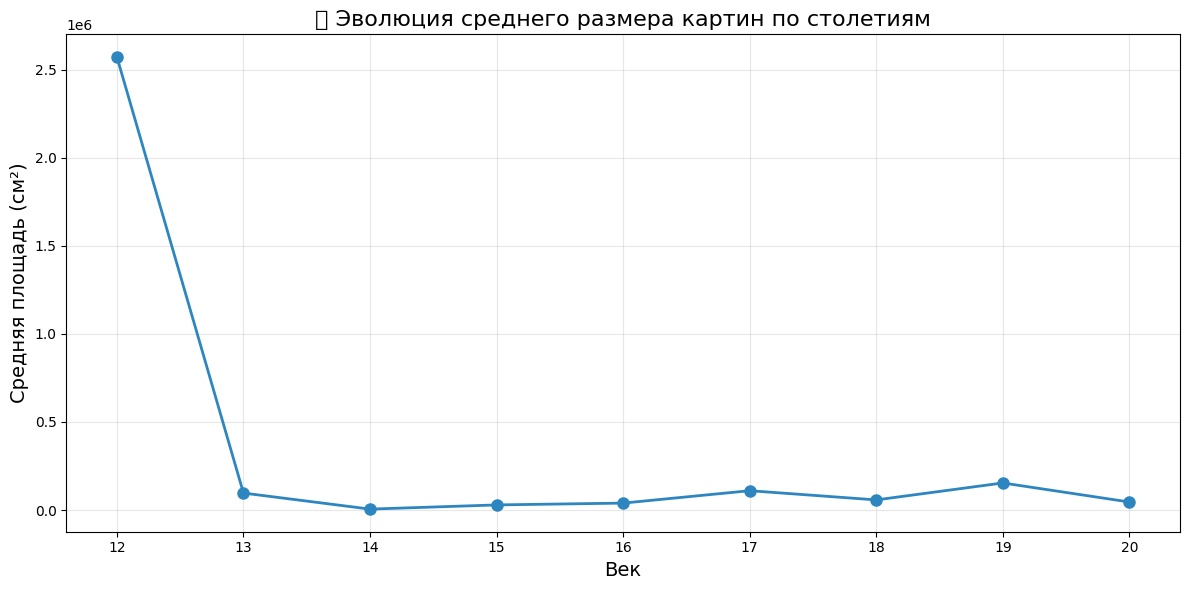

💡 Инсайт: Размеры картин резко выросли в XVII и XIX веках, достигнув пика в XX веке. Самые маленькие полотна создавались в XIV веке.


In [2]:
# График 1. Эволюция среднего размера картин по столетиям
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Убедимся, что столбцы area и century существуют
if "area" not in df_paintings.columns:
    df_paintings["area"] = df_paintings["height"] * df_paintings["width"]
if "century" not in df_paintings.columns:
    df_paintings["century"] = (df_paintings["creationYear"] - 1) // 100 + 1

plt.figure(figsize=(12, 6))

century_avg = df_paintings.groupby("century")["area"].mean().reset_index()

plt.plot(century_avg["century"], century_avg["area"], marker="o", linestyle="-",
         linewidth=2, markersize=8, color="#2E86C1")
plt.title("📈 Эволюция среднего размера картин по столетиям", fontsize=16)
plt.xlabel("Век", fontsize=14)
plt.ylabel("Средняя площадь (см²)", fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(century_avg["century"])
plt.tight_layout()
plt.show()

print("💡 Инсайт: Размеры картин резко выросли в XVII и XIX веках, достигнув пика в XX веке. Самые маленькие полотна создавались в XIV веке.")

### График 2. Столбчатая диаграмма: Топ‑10 стран по количеству картин

**Что показывает:** Распределение картин по странам происхождения (только топ-10).

**Зачем:** Понять, какие национальные школы живописи наиболее представлены в датасете, и оценить географический охват коллекции.

/tmp/ipykernel_1902/1833298131.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="coolwarm")
/tmp/ipykernel_1902/1833298131.py:10: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127757 (\N{EARTH GLOBE EUROPE-AFRICA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


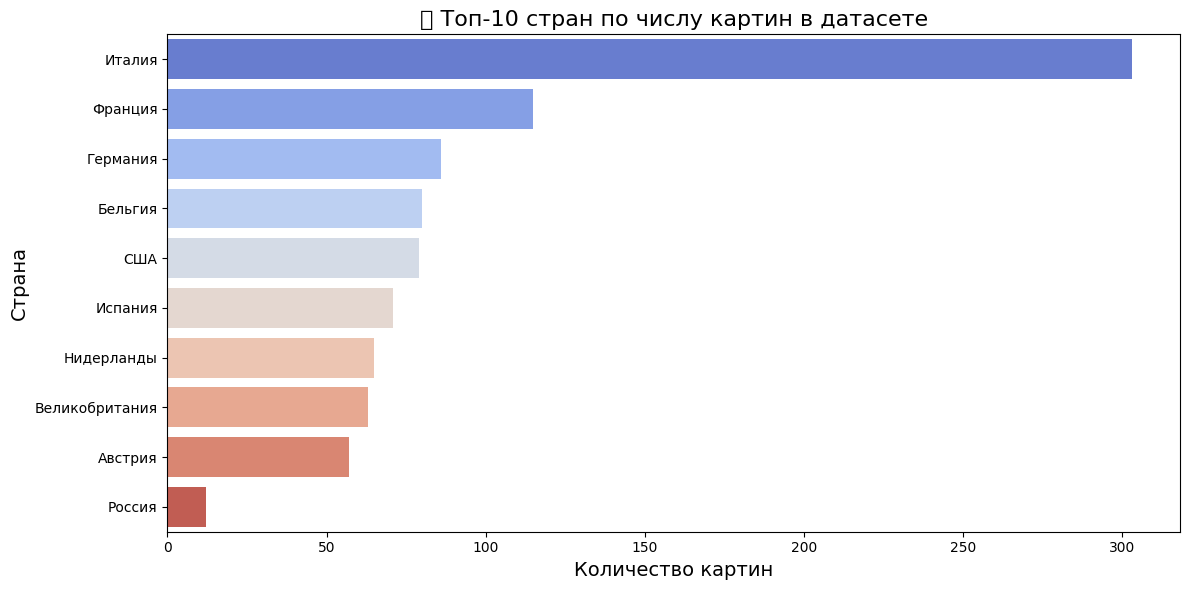

💡 Инсайт: Италия доминирует с большим отрывом, за ней следуют Франция и Германия. Это отражает исторические центры европейского искусства.


In [3]:
# График 2. Топ-10 стран по количеству картин
plt.figure(figsize=(12, 6))

top_countries = df_paintings["country"].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette="coolwarm")

plt.title("🌍 Топ-10 стран по числу картин в датасете", fontsize=16)
plt.xlabel("Количество картин", fontsize=14)
plt.ylabel("Страна", fontsize=14)
plt.tight_layout()
plt.show()

print("💡 Инсайт: Италия доминирует с большим отрывом, за ней следуют Франция и Германия. Это отражает исторические центры европейского искусства.")

### График 3. Столбчатая диаграмма: Топ‑10 материалов

**Что показывает:** Самые популярные основы (материалы), на которых написаны картины.

**Зачем:** Увидеть, какие технологии преобладали в живописи, и оценить разнообразие используемых материалов.

/tmp/ipykernel_1902/2322466788.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_materials.values, y=top_materials.index, palette="magma")
/tmp/ipykernel_1902/2322466788.py:10: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


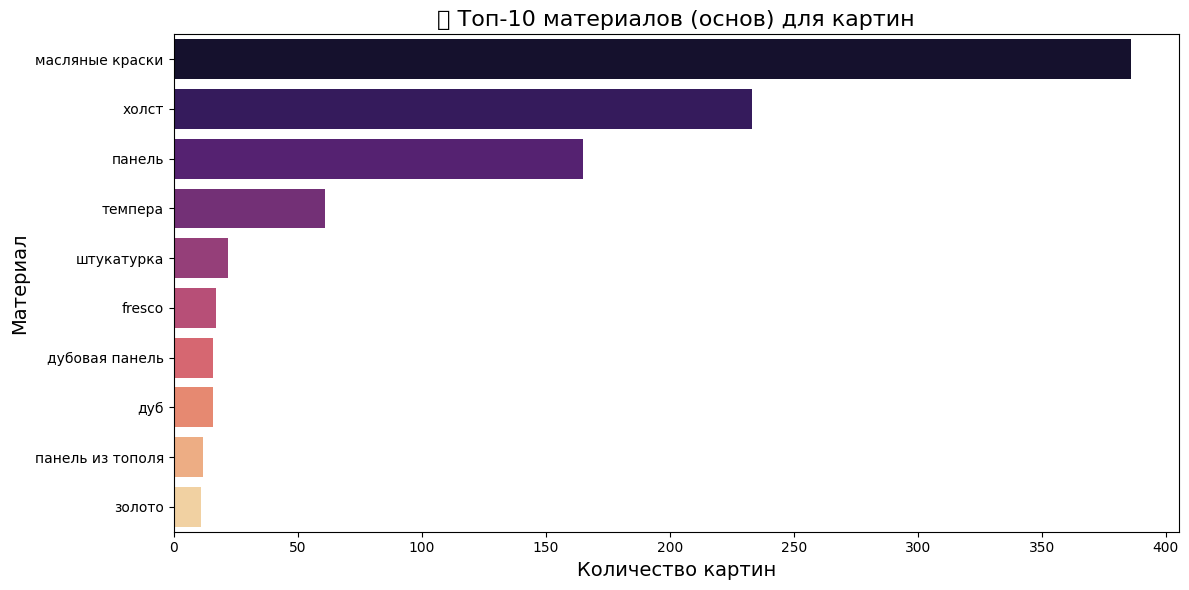

💡 Инсайт: Масляные краски и холст – явные лидеры. Панель (дерево) занимает третье место, что говорит о переходе от деревянных основ к холсту в эпоху Возрождения.


In [4]:
# График 3. Топ-10 материалов
plt.figure(figsize=(12, 6))

top_materials = df_paintings["material"].value_counts().head(10)
sns.barplot(x=top_materials.values, y=top_materials.index, palette="magma")

plt.title("🎨 Топ-10 материалов (основ) для картин", fontsize=16)
plt.xlabel("Количество картин", fontsize=14)
plt.ylabel("Материал", fontsize=14)
plt.tight_layout()
plt.show()

print("💡 Инсайт: Масляные краски и холст – явные лидеры. Панель (дерево) занимает третье место, что говорит о переходе от деревянных основ к холсту в эпоху Возрождения.")

### График 4. Ящик с усами (Box plot): распределение площади по векам

**Что показывает:** Разброс размеров картин внутри каждого века, медиану, квартили и выбросы.

**Зачем:** Оценить, насколько однородны размеры в разные эпохи, и выявить аномально большие или маленькие работы.

/tmp/ipykernel_1902/3541192184.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="century", y="area", data=df_box, palette="Set2", showfliers=True)
/tmp/ipykernel_1902/3541192184.py:14: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


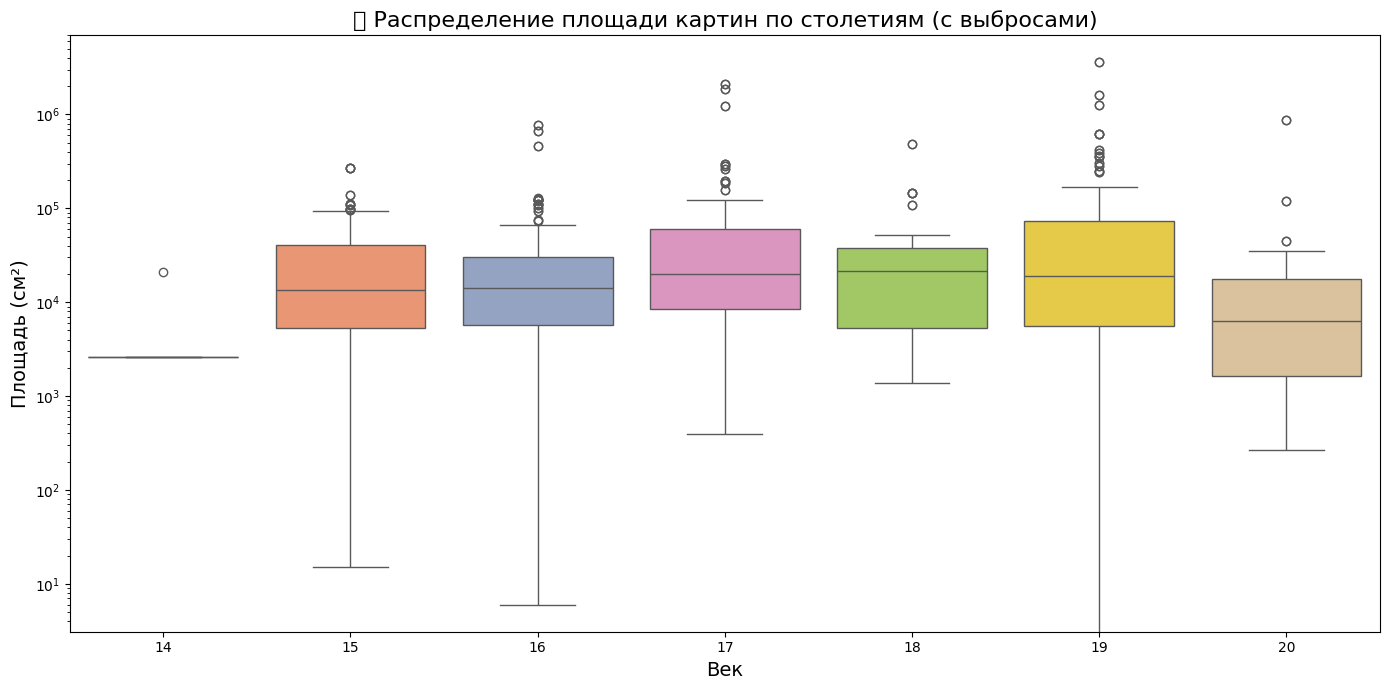

💡 Инсайт: В каждом веке есть гигантские полотна (выбросы), но медиана размеров росла до XVII века, а затем стабилизировалась. Логарифмическая шкала показывает широкий диапазон размеров внутри каждого периода.


In [5]:
# График 4. Box plot: распределение площади по векам
plt.figure(figsize=(14, 7))

# Оставляем только века, в которых больше 5 картин
centuries_with_data = df_paintings["century"].value_counts()[df_paintings["century"].value_counts() > 5].index
df_box = df_paintings[df_paintings["century"].isin(centuries_with_data)]

sns.boxplot(x="century", y="area", data=df_box, palette="Set2", showfliers=True)

plt.title("📦 Распределение площади картин по столетиям (с выбросами)", fontsize=16)
plt.xlabel("Век", fontsize=14)
plt.ylabel("Площадь (см²)", fontsize=14)
plt.yscale("log")  # логарифмическая шкала для лучшего отображения
plt.tight_layout()
plt.show()

print("💡 Инсайт: В каждом веке есть гигантские полотна (выбросы), но медиана размеров росла до XVII века, а затем стабилизировалась. Логарифмическая шкала показывает широкий диапазон размеров внутри каждого периода.")

### График 5. Точечная диаграмма (Scatter plot): высота vs ширина, цвет по столетию

**Что показывает:** Связь между высотой и шириной картин, при этом точки окрашены в соответствии с веком создания.

**Зачем:** Обнаружить, есть ли предпочтения в форматах (вертикальные, горизонтальные, квадратные) в разные эпохи, и как менялось соотношение сторон.

/tmp/ipykernel_1902/1142848145.py:18: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128208 (\N{TRIANGULAR RULER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


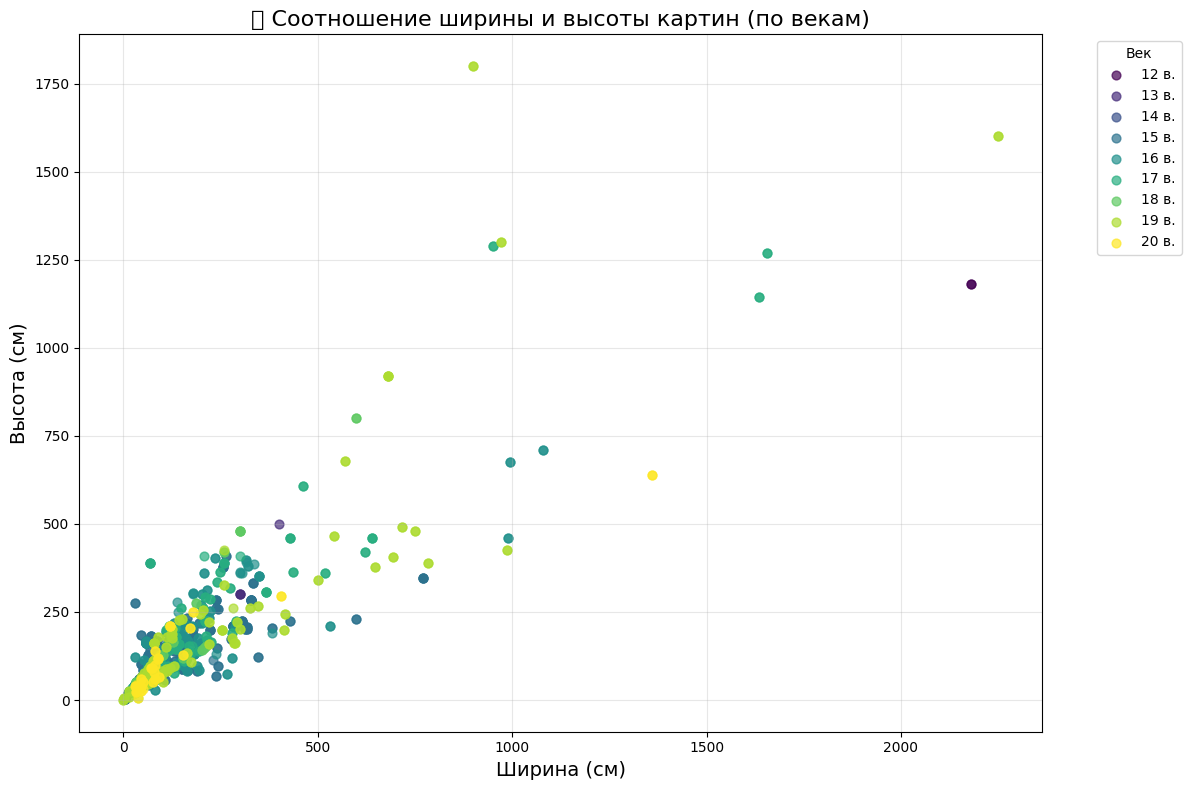

💡 Инсайт: Большинство картин имеют высоту больше ширины (вертикальный формат). Однако в некоторые века (например, 19-й) появляется больше горизонтальных работ. Также видны кластеры разных эпох.


In [6]:
# График 5. Scatter plot: высота vs ширина, цвет по столетию
plt.figure(figsize=(12, 8))

centuries = sorted(df_paintings["century"].unique())
colors = plt.cm.viridis(np.linspace(0, 1, len(centuries)))
color_map = {c: colors[i] for i, c in enumerate(centuries)}

for century in centuries:
    subset = df_paintings[df_paintings["century"] == century]
    plt.scatter(subset["width"], subset["height"],
                color=color_map[century], label=f"{century} в.", alpha=0.7, s=40)

plt.title("📐 Соотношение ширины и высоты картин (по векам)", fontsize=16)
plt.xlabel("Ширина (см)", fontsize=14)
plt.ylabel("Высота (см)", fontsize=14)
plt.legend(title="Век", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("💡 Инсайт: Большинство картин имеют высоту больше ширины (вертикальный формат). Однако в некоторые века (например, 19-й) появляется больше горизонтальных работ. Также видны кластеры разных эпох.")

### График 6. Тепловая карта корреляции числовых признаков

**Что показывает:** Коэффициенты корреляции Пирсона между парами числовых переменных (высота, ширина, площадь, год создания).

**Зачем:** Понять, какие признаки связаны друг с другом, и есть ли связь между годом создания и размерами.

/tmp/ipykernel_1902/2280739231.py:11: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


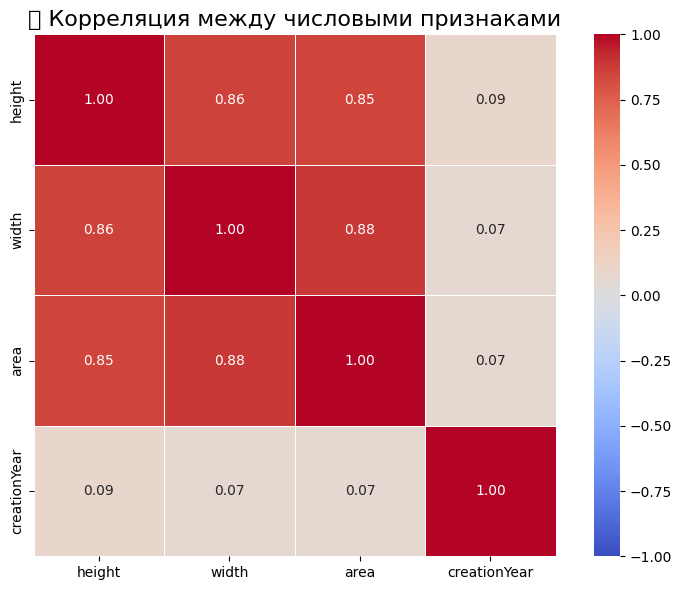

💡 Инсайт: Сильная положительная корреляция между высотой и шириной (и, соответственно, площадью) ожидаема. Год создания почти не коррелирует с размерами, что говорит о стабильности предпочтений в масштабах на протяжении веков.


In [7]:
# График 6. Тепловая карта корреляции
plt.figure(figsize=(8, 6))

numeric_cols = ["height", "width", "area", "creationYear"]
corr = df_paintings[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, cbar=True,
            square=True, vmin=-1, vmax=1)

plt.title("🔥 Корреляция между числовыми признаками", fontsize=16)
plt.tight_layout()
plt.show()

print("💡 Инсайт: Сильная положительная корреляция между высотой и шириной (и, соответственно, площадью) ожидаема. Год создания почти не коррелирует с размерами, что говорит о стабильности предпочтений в масштабах на протяжении веков.")

### График 7. Круговая диаграмма (Pie): доля основных материалов

**Что показывает:** Долевое распределение топ-6 материалов в процентах от общего числа картин.

**Зачем:** Наглядно сравнить популярность разных основ, дополнив столбчатую диаграмму относительными долями.

/tmp/ipykernel_1902/2893945884.py:14: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


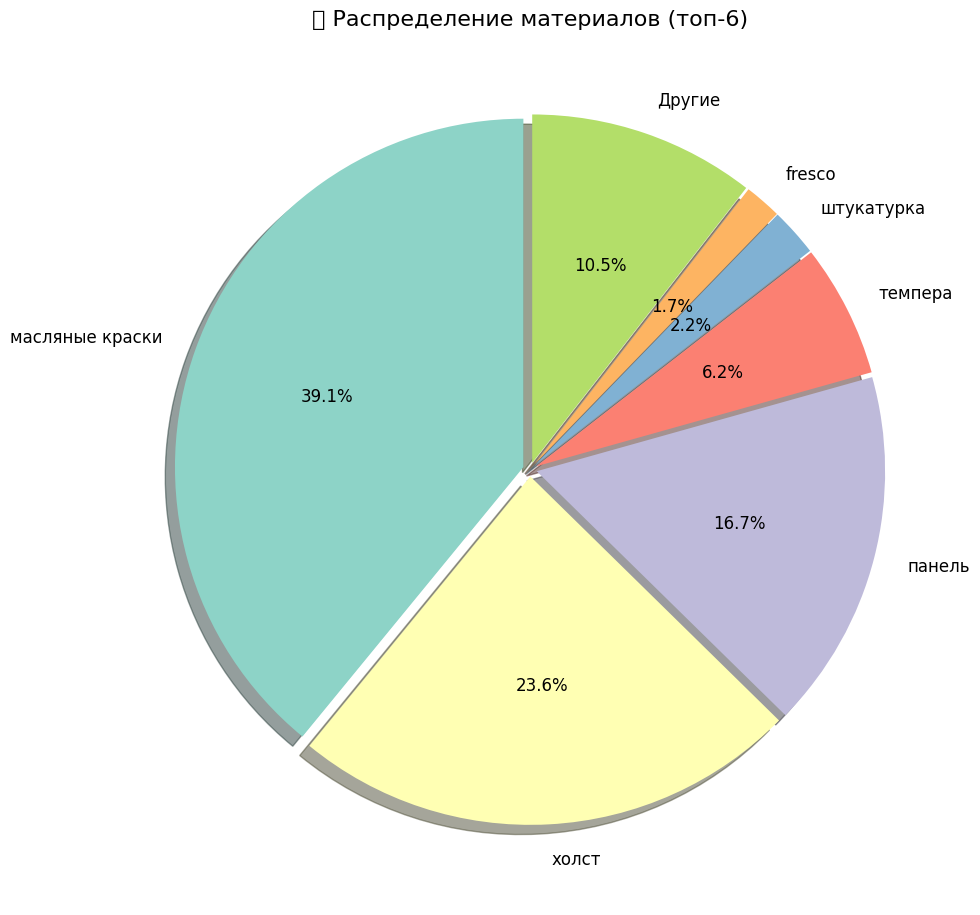

💡 Инсайт: Масляные краски составляют почти 40% всех картин. Холст и панель вместе занимают около 40%, а оставшиеся 20% приходятся на десятки других материалов – это говорит о большом разнообразии техник в живописи.


In [8]:
# График 7. Круговая диаграмма топ-6 материалов
plt.figure(figsize=(10, 10))

top6_materials = df_paintings["material"].value_counts().head(6)
other_count = df_paintings["material"].value_counts().iloc[6:].sum()
if other_count > 0:
    top6_materials["Другие"] = other_count

plt.pie(top6_materials.values, labels=top6_materials.index, autopct="%1.1f%%",
        startangle=90, colors=sns.color_palette("Set3", len(top6_materials)),
        explode=[0.02]*len(top6_materials), shadow=True, textprops={"fontsize": 12})

plt.title("🧩 Распределение материалов (топ-6)", fontsize=16)
plt.tight_layout()
plt.show()

print("💡 Инсайт: Масляные краски составляют почти 40% всех картин. Холст и панель вместе занимают около 40%, а оставшиеся 20% приходятся на десятки других материалов – это говорит о большом разнообразии техник в живописи.")

## 🎯 Итоги визуализации

Мы построили 7 графиков, которые раскрыли ключевые закономерности:

1. **Размеры** картин менялись волнообразно, с пиками в XVII и XIX веках.
2. **Географически** доминирует Италия, но представлены и другие европейские страны.
3. **Материалы**: масло и холст — бесспорные лидеры, но есть и множество редких основ.
4. В каждом веке есть **гигантские полотна**, но медианные размеры стабильны.
5. **Форматы** в основном вертикальные, но в XIX веке появляется больше горизонтальных работ.
6. **Корреляция** между годом и размерами практически отсутствует.
7. Разнообразие материалов велико, но топ-6 покрывает более 80% всех картин.

Теперь мы готовы к более сложному анализу и созданию интерактивных дашбордов! 🚀